In [2]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [3]:
torch.backends.mkldnn.enabled = True

In [4]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [5]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [6]:
model6_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model6_0)
describe(model6_0)

MACs: 5.53 MMac, Params: 56.07 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model6_0.pt
Starting
Epoch 1/60: Train loss = 1.1296, Train accuracy = 0.6019, Test loss = 1.1159, Test accuracy = 0.6090
Epoch 2/60: Train loss = 0.9264, Train accuracy = 0.6713, Test loss = 0.9233, Test accuracy = 0.6800
Epoch 3/60: Train loss = 0.8207, Train accuracy = 0.7123, Test loss = 0.8003, Test accuracy = 0.7246
Epoch 4/60: Train loss = 0.7204, Train accuracy = 0.7503, Test loss = 0.7207, Test accuracy = 0.7541
Epoch 5/60: Train loss = 0.6336, Train accuracy = 0.7792, Test loss = 0.6463, Test accuracy = 0.7786
Epoch 6/60: Train loss = 0.6372, Train accuracy = 0.7793, Test loss = 0.6453, Test accuracy = 0.7785
Epoch 7/60: Train loss = 0.6014, Train accuracy = 0.7898, Test loss = 0.6322, Test accuracy = 0.7830
Epoch 8/60: Train loss = 0.5766, Train accuracy = 0.8003, Test loss = 0.6106, Test accuracy = 0.7908
Epoch 9/60: Train loss = 0.5547, Train accuracy = 0.8063, Test loss = 0.5826, Test accuracy = 0.7997
Epoch 10/60: Train loss = 0.5697

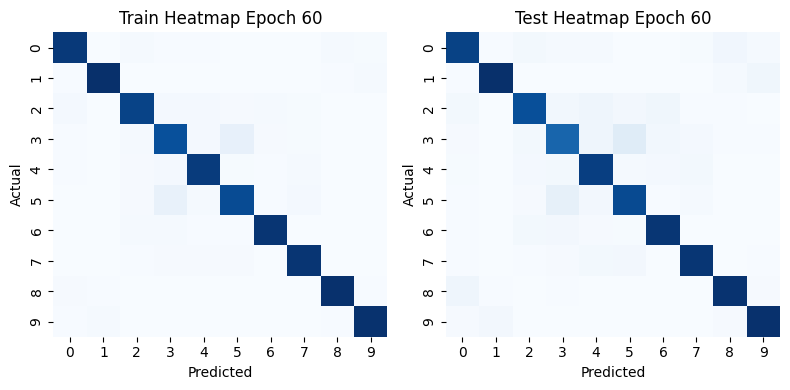

<Figure size 1200x600 with 0 Axes>

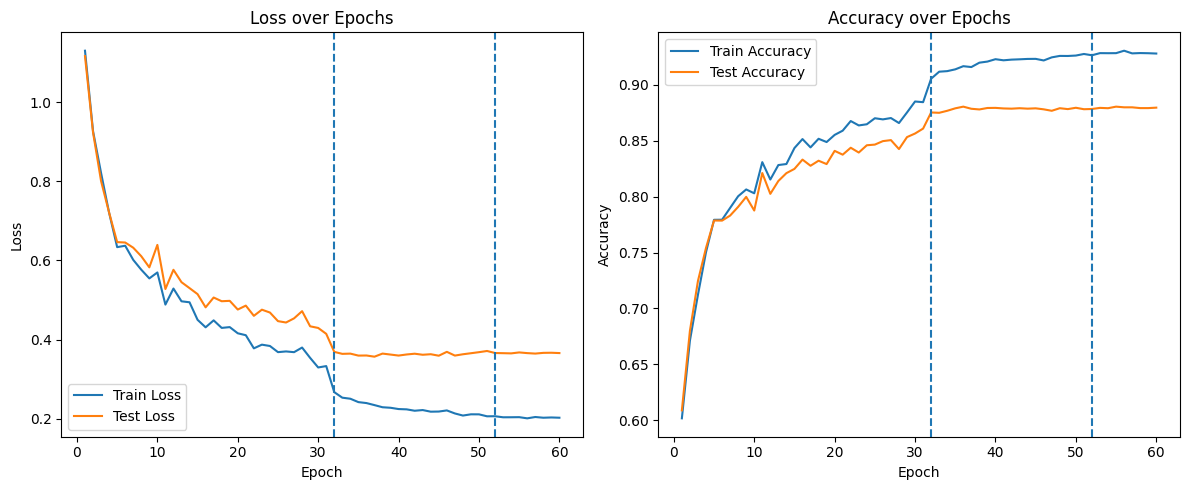

In [7]:
trainf32(model6_0,"model_weights/model6_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [8]:
model6_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model6_1)
describe(model6_1)

MACs: 5.53 MMac, Params: 56.07 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model6_1.pt
Starting
Epoch 1/60: Train loss = 0.9177, Train accuracy = 0.6778, Test loss = 0.8719, Test accuracy = 0.6896
Epoch 2/60: Train loss = 0.9183, Train accuracy = 0.6945, Test loss = 0.9149, Test accuracy = 0.6996
Epoch 3/60: Train loss = 0.7453, Train accuracy = 0.7379, Test loss = 0.7718, Test accuracy = 0.7312
Epoch 4/60: Train loss = 0.6421, Train accuracy = 0.7794, Test loss = 0.6588, Test accuracy = 0.7719
Epoch 5/60: Train loss = 0.5583, Train accuracy = 0.8070, Test loss = 0.5739, Test accuracy = 0.8071
Epoch 6/60: Train loss = 0.5554, Train accuracy = 0.8105, Test loss = 0.5863, Test accuracy = 0.7982
Epoch 7/60: Train loss = 0.5112, Train accuracy = 0.8217, Test loss = 0.5478, Test accuracy = 0.8165
Epoch 8/60: Train loss = 0.5079, Train accuracy = 0.8235, Test loss = 0.5562, Test accuracy = 0.8115
Epoch 9/60: Train loss = 0.4766, Train accuracy = 0.8333, Test loss = 0.5223, Test accuracy = 0.8222
Epoch 10/60: Train loss = 0.5147

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 27/60: Train loss = 0.3529, Train accuracy = 0.8752, Test loss = 0.4374, Test accuracy = 0.8522
Epoch 28/60: Train loss = 0.3234, Train accuracy = 0.8865, Test loss = 0.4202, Test accuracy = 0.8593
Epoch 29/60: Train loss = 0.3278, Train accuracy = 0.8853, Test loss = 0.4177, Test accuracy = 0.8612
Epoch 30/60: Train loss = 0.3146, Train accuracy = 0.8914, Test loss = 0.4137, Test accuracy = 0.8586
Epoch 31/60: Train loss = 0.3366, Train accuracy = 0.8813, Test loss = 0.4445, Test accuracy = 0.8539
Epoch 32/60: Train loss = 0.2560, Train accuracy = 0.9110, Test loss = 0.3714, Test accuracy = 0.8787
Epoch 33/60: Train loss = 0.2422, Train accuracy = 0.9164, Test loss = 0.3641, Test accuracy = 0.8784
Epoch 34/60: Train loss = 0.2398, Train accuracy = 0.9156, Test loss = 0.3653, Test accuracy = 0.8845
Epoch 35/60: Train loss = 0.2323, Train accuracy = 0.9184, Test loss = 0.3659, Test accuracy = 0.8810
Epoch 36/60: Train loss = 0.2286, Train accuracy = 0.9198, Test loss = 0.3605, Tes

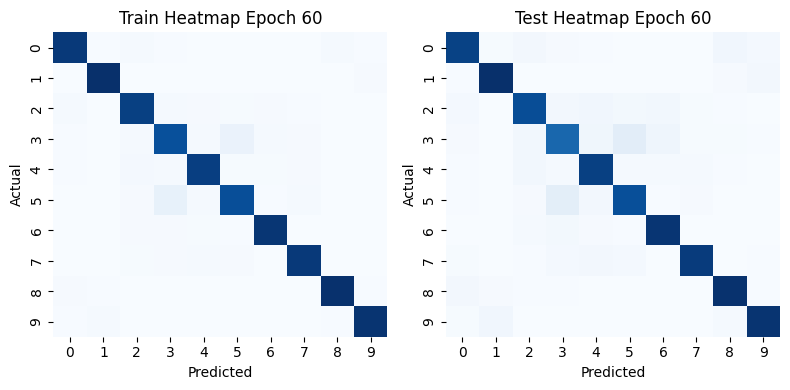

<Figure size 1200x600 with 0 Axes>

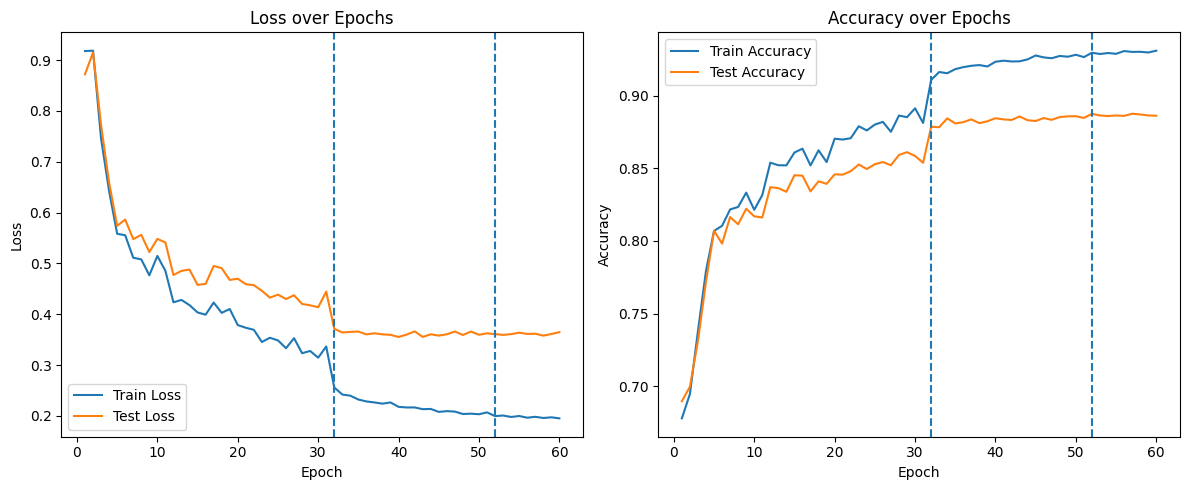

In [9]:
trainf32(model6_1,"model_weights/model6_1.pt",criterion,train_dataset,val_dataset, batch_size=64)